# Try to optimise a gaussian pulse in ccd


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
steel_blue, plum = "#4682B4", "#B44682"

## Create Gaussian Pulse Func

In [4]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-5
evaluation_points = 2000
evaluation_time = 4/rabi_freq

In [86]:

def make_gaussian_ccd_pulse(amplitude_scale=1.0, epsilon_ratio=1/16, sigma_frac=0.25):
    """
    Returns a CCD pulse function using a Gaussian Ω(t), parameterised for optimisation.
    
    Parameters:
    - amplitude_scale: scaling factor on Gaussian peak to hit target area
    - epsilon_ratio: ε_m(t) = epsilon_ratio * Ω(t)
    - phase_freq_ratio: ω_m(t) = phase_freq_ratio * Ω(t)
    """

    # Nominal Rabi freq to define gate duration
    rabi_freq = 0.005  # rad/ns
    T = 4 / rabi_freq

    sigma = T*sigma_frac
    centre = T / 2



    def pulse(t, detuning):
        rabi_freq_t = amplitude_scale * rabi_freq * np.exp(-((t - centre)**2) / (2 * sigma**2))
        epsilon_m = epsilon_ratio * rabi_freq_t
        phase_freq = rabi_freq

        return {
            'natural_freq': 10 - detuning,
            'driving_freq': 10,
            'rabi_freq': rabi_freq_t,
            'phi_0': 0.48507178493 * np.pi,
            'epsilon_m': epsilon_m,
            'phase_freq': phase_freq,
            'theta_m': -0.49999999969 * np.pi,
        }

    return pulse




In [109]:
import numpy as np
from scipy.optimize import minimize

evaluation_points = 2000
evaluation_time = 4/rabi_freq


# Define target root-X gate
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])

# Objective function: 1 - fidelity (since we are minimising)
def objective(params):
    amplitude_scale, epsilon_ratio, sigma_frac = params
    ccd_pulse = make_gaussian_ccd_pulse(amplitude_scale, epsilon_ratio, sigma_frac)

    try:
        times, Us = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, ccd_pulse, detuning=0)
       
        fid = qt.calculate_fidelities(root_x, Us, 2)
        return 1 - fid[-1]  # We want to maximise fidelity, so minimise 1 - fidelity

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return 1  # Return high loss if something breaks

# Initial guess and bounds



# Run optimisation




# result = dual_annealing(objective, bounds=[(1, 10), (0, 1/16), (0.01, 1)], maxiter=1000)

# Extract and print optimal values

for a in np.linspace(2, 10, 1000):
    initial_guess = [a, 1/16, 1/6]
    bounds = [(0.5, 10), (0, 1/16), (0.01, 0.5)]
    result = minimize(objective, initial_guess,bounds=bounds, method='L-BFGS-B')
    optimal_amplitude_scale, optimal_epsilon_ratio, optimal_sigma_frac = result.x
    optimal_fidelity = 1 - result.fun

    if optimal_fidelity > 0.999:
        break
    print(f"Amplitude Scale: {optimal_amplitude_scale}, Epsilon Ratio: {optimal_epsilon_ratio}, Sigma Fraction: {optimal_sigma_frac}, Fidelity: {optimal_fidelity}")

print(f"✅ Optimal Amplitude Scale: {optimal_amplitude_scale}")
print(f"✅ Optimal Epsilon Ratio: {optimal_epsilon_ratio}")
print(f"✅ Optimal Sigma Fraction: {optimal_sigma_frac}")
print(f"🎯 Max Fidelity: {optimal_fidelity}")

ccd_pulse = make_gaussian_ccd_pulse(optimal_amplitude_scale, optimal_epsilon_ratio, optimal_sigma_frac)


KeyboardInterrupt: 

✅ Optimal Amplitude Scale: 1.0380154520561686
✅ Optimal Epsilon Ratio: 0.0625
✅ Optimal Sigma Fraction: 1.0
🎯 Max Fidelity: 0.999955275041068

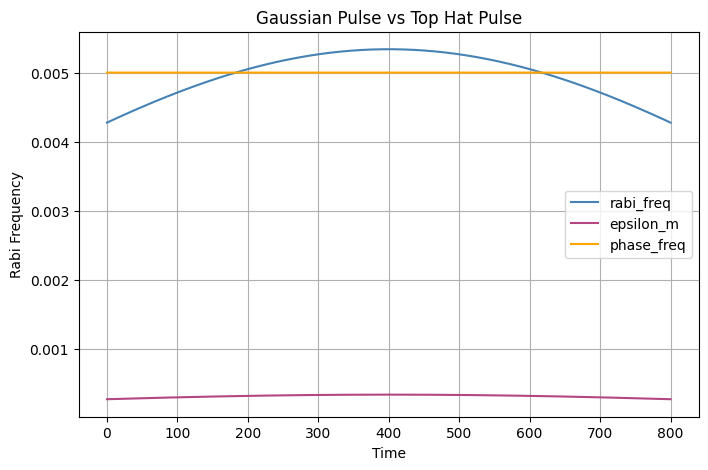

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_22327/330939330.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gaussian_pulse_area = np.trapz(gauss_pulse_values, times)


In [105]:
# create times
times = np.linspace(0, evaluation_time, evaluation_points)

# Generate pulse values over time using the top hat pulse function

gauss_pulse_values = [ccd_pulse(t, 0)['rabi_freq'] for t in times]

# Plot the pulses
plt.figure(figsize=(8, 5))
plt.plot(times, [ccd_pulse(t, 0)['rabi_freq'] for t in times], label='rabi_freq', color=steel_blue)
plt.plot(times, [ccd_pulse(t, 0)['epsilon_m'] for t in times], label='epsilon_m', color=plum)
plt.plot(times, [ccd_pulse(t, 0)['phase_freq'] for t in times], label='phase_freq', color='orange')
plt.xlabel('Time')
plt.ylabel('Rabi Frequency')
plt.title('Gaussian Pulse vs Top Hat Pulse')
plt.legend()
plt.grid()
plt.show()

# Calculate the area of the Gaussian pulse
gaussian_pulse_area = np.trapz(gauss_pulse_values, times)



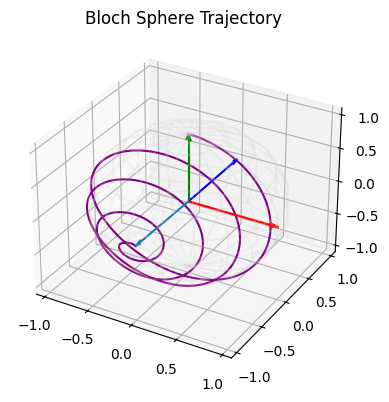

In [101]:
times, Us_gauss = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, ccd_pulse, detuning=0)
initial_state = np.array([1+0j,0+0j])

states = []
for U in Us_gauss:
    states.append(U @ initial_state)
states = np.array(states)

qt.visualise_solution(times, states)


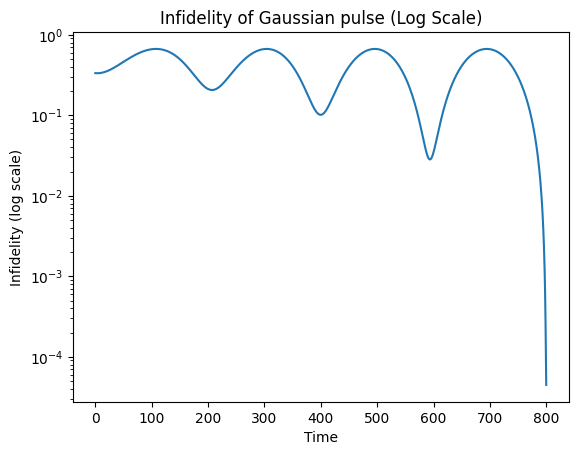

In [102]:
infids = 1 - qt.calculate_fidelities(root_x, Us_gauss, 2)

# Plot infidelity against time on a log scale
plt.figure()
plt.plot(times, infids)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Infidelity (log scale)")
plt.title("Infidelity of Gaussian pulse (Log Scale)")
plt.show()

## TBH I hate this root X - but lets try cross talk

In [97]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, ccd_pulse, detuning=detuning)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_ccd_gauss = [fid[-1] for fid in fids_2]

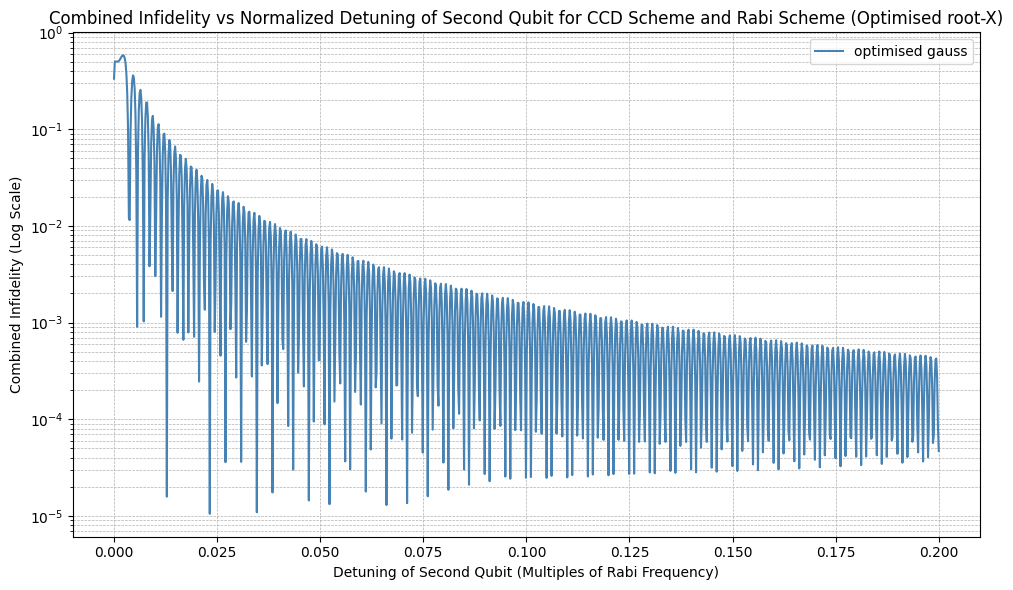

In [98]:
# find combdined infidelity
infidelities_2_ccd_gauss = 1-np.array(final_fids_2_ccd_gauss)




# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_ccd_gauss, label="optimised gauss", color=steel_blue)


plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("dirty_root_x_scaling.png", dpi=300)
plt.show()

